기준값 로드 완료
  C1 (1-JSD)   : 0.9559
  C2 (|rho|)   : 0.8896
  C3 (CosSim)  : 0.9485
  CMVTS        : 0.9338

[Analysis 1] Weight Grid Search (step=0.1)
  탐색 시나리오 수 : 36개
  CMVTS 범위      : 0.9021 ~ 0.9485
  평균            : 0.9313
  표준편차        : 0.0126
  0.80 이상 비율  : 100.0%
  0.60 이상 비율  : 100.0%

[Analysis 2] JSD Proxy Distribution Sensitivity
  Proxy assumption             1-JSD    CMVTS
  --------------------------------------------
  Uniform (baseline)          0.9559   0.9338 ← baseline
  Right-skewed                0.7808   0.8638
  Left-skewed                 0.7777   0.8625
  Normal                      0.7266   0.8421

  CMVTS 변동폭 : 0.0917

[Analysis 3] CosSim Stability by Indicator Count
  Subset                            n   CosSim    CMVTS
  ------------------------------------------------
  All indicators (baseline)        34   0.9485   0.9338 ← baseline
  Excl. Country Overview           30   0.9438   0.9324
  Excl. eCommerce                  15   0.9407   0.9314
  Excl. T

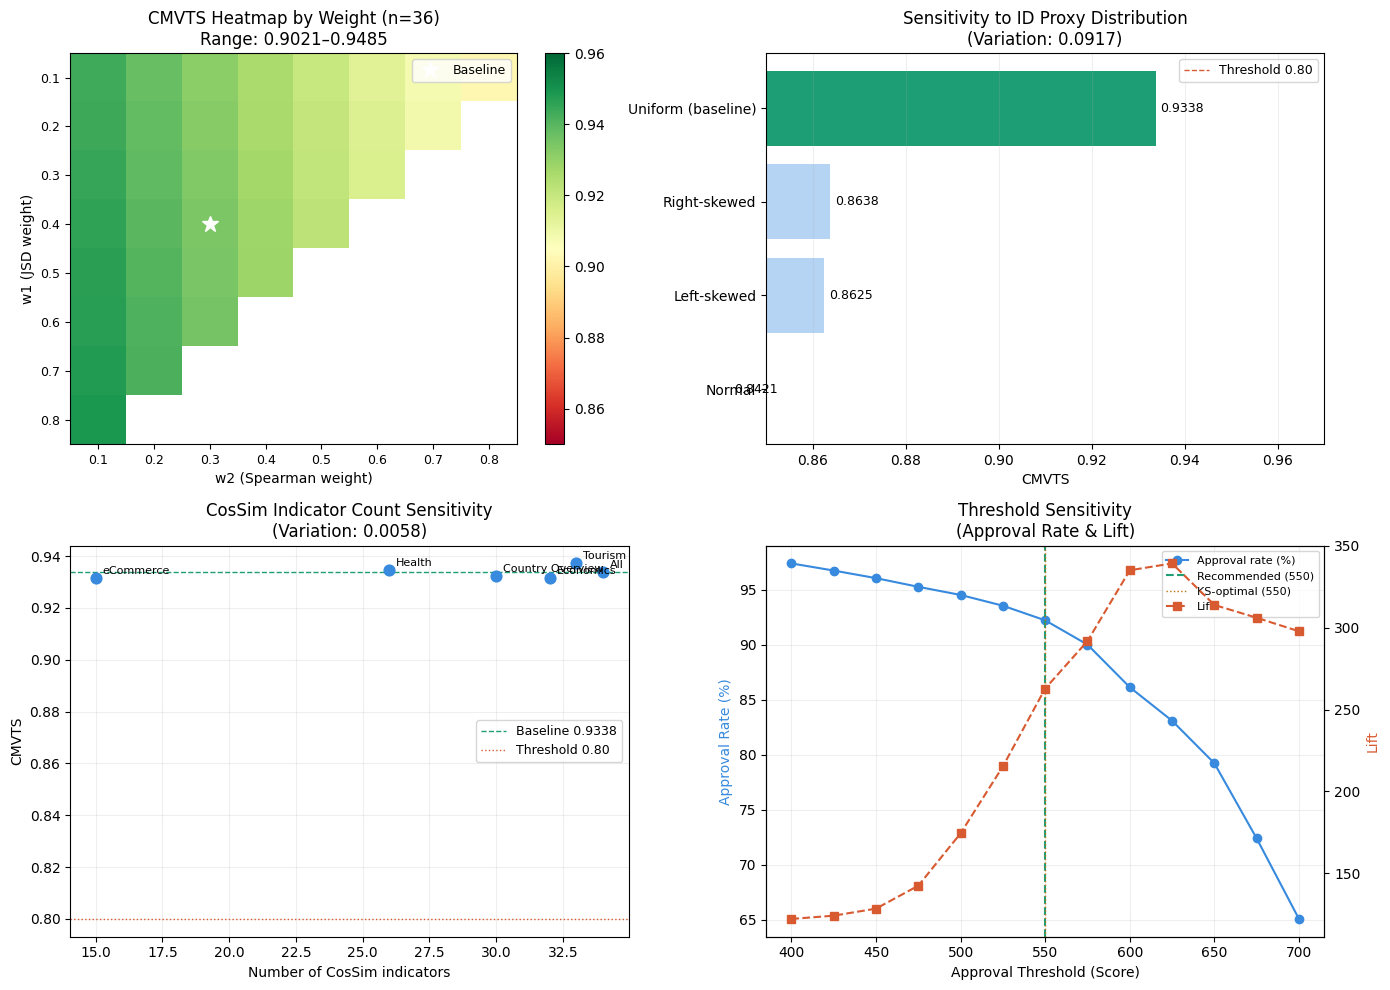


  Sensitivity Analysis — Overall Stability Summary
  항목                                       변동폭         판정
  --------------------------------------------------------
  Weight grid (n=28 scenarios)          0.0464     Stable
  JSD proxy distribution (4 types)      0.0917   Moderate
  CosSim indicator subset               0.0058     Stable

  전체 판정 : MODERATE — 일부 시나리오 검토 권고
  0.80 임계값 초과 비율 (가중치 grid) : 100.0%

저장 완료:
  outputs/tables/06_weight_grid.csv
  outputs/tables/06_jsd_sensitivity.csv
  outputs/tables/06_cossim_stability.csv
  outputs/tables/06_threshold_sensitivity.csv
  outputs/figures/06_sensitivity_analysis.png

→ 07_paper_figures_tables.ipynb 진행


In [1]:
# ============================================================
# 06_sensitivity_analysis
# CMVTS 민감도 분석
# 1) 가중치 변화 안정성 (grid search)
# 2) 인도네시아 프록시 분포 가정 안정성 (JSD)
# 3) CosSim 입력 지표 수 안정성
# 4) 임계값(승인 기준) 민감도
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle
import warnings
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
from itertools import product
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 기준값 로드 (04번 결과)
with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

final_vars  = pd.read_csv('outputs/tables/03_final_vars.csv')['variable'].tolist()
iv_df       = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
statista_df = pd.read_csv('data/indonesia_korea_statistics.csv')
cmvts_base  = pd.read_csv('outputs/tables/04_cmvts_results.csv')
sens_base   = pd.read_csv('outputs/tables/04_sensitivity.csv')

# 기준 컴포넌트값
C1 = cmvts_base[cmvts_base['component']=='1-JSD_mean']['value'].values[0]
C2 = cmvts_base[cmvts_base['component']=='|Spearman_rho|']['value'].values[0]
C3 = cmvts_base[cmvts_base['component']=='CosSim']['value'].values[0]
CMVTS_BASE = cmvts_base[cmvts_base['component']=='CMVTS']['value'].values[0]

print(f"기준값 로드 완료")
print(f"  C1 (1-JSD)   : {C1:.4f}")
print(f"  C2 (|rho|)   : {C2:.4f}")
print(f"  C3 (CosSim)  : {C3:.4f}")
print(f"  CMVTS        : {CMVTS_BASE:.4f}")

# %% [3] ── 분석 1: 가중치 Grid Search ──────────────────────────
# w1+w2+w3=1 제약 하에 0.1 단위로 전수 탐색
print("\n[Analysis 1] Weight Grid Search (step=0.1)")

grid_results = []
for w1 in np.arange(0.1, 0.9, 0.1):
    for w2 in np.arange(0.1, 0.9 - w1 + 0.01, 0.1):
        w3 = round(1 - w1 - w2, 2)
        if w3 < 0.1 or w3 > 0.8:
            continue
        cmvts = w1*C1 + w2*C2 + w3*C3
        grid_results.append({
            'w1': round(w1,1), 'w2': round(w2,1), 'w3': round(w3,1),
            'cmvts': round(cmvts, 4)
        })

grid_df = pd.DataFrame(grid_results)

print(f"  탐색 시나리오 수 : {len(grid_df)}개")
print(f"  CMVTS 범위      : {grid_df['cmvts'].min():.4f} ~ "
      f"{grid_df['cmvts'].max():.4f}")
print(f"  평균            : {grid_df['cmvts'].mean():.4f}")
print(f"  표준편차        : {grid_df['cmvts'].std():.4f}")
print(f"  0.80 이상 비율  : "
      f"{(grid_df['cmvts']>=0.80).sum()/len(grid_df)*100:.1f}%")
print(f"  0.60 이상 비율  : "
      f"{(grid_df['cmvts']>=0.60).sum()/len(grid_df)*100:.1f}%")

# %% [4] ── 분석 2: JSD 프록시 분포 가정 안정성 ─────────────────
# 인도네시아 분포를 균등분포(기본) 외 다른 분포로 가정했을 때 JSD 변화
print("\n[Analysis 2] JSD Proxy Distribution Sensitivity")

def calc_jsd_mean(dist_type='uniform'):
    """dist_type: 'uniform' | 'right_skew' | 'left_skew' | 'normal'"""
    jsd_vals = []
    for var in final_vars:
        if var not in bins_all:
            continue
        bin_df = bins_all[var]
        good_col = 'good' if 'good' in bin_df.columns else 'count_distr'
        bad_col  = 'bad'  if 'bad'  in bin_df.columns else None

        if bad_col and bad_col in bin_df.columns:
            total     = bin_df[good_col] + bin_df[bad_col]
            good_rate = bin_df[good_col] / total.replace(0, np.nan)
        else:
            good_rate = bin_df[good_col]

        dist  = good_rate.dropna().values
        dist  = np.where(dist <= 0, 1e-6, dist)
        korea = dist / dist.sum()
        n     = len(korea)

        if   dist_type == 'uniform':
            id_dist = np.ones(n) / n
        elif dist_type == 'right_skew':
            id_dist = np.array([1/(i+1) for i in range(n)], dtype=float)
            id_dist /= id_dist.sum()
        elif dist_type == 'left_skew':
            id_dist = np.array([1/(n-i) for i in range(n)], dtype=float)
            id_dist /= id_dist.sum()
        elif dist_type == 'normal':
            mid = n / 2
            id_dist = np.array([np.exp(-0.5*((i-mid)/(n/4))**2)
                                 for i in range(n)], dtype=float)
            id_dist /= id_dist.sum()
        else:
            id_dist = np.ones(n) / n

        id_dist = np.where(id_dist <= 0, 1e-6, id_dist)
        jsd_vals.append(jensenshannon(korea, id_dist, base=2))

    jsd_mean = np.mean(jsd_vals)
    return round(1 - jsd_mean, 4)

proxy_scenarios = {
    'Uniform (baseline)' : 'uniform',
    'Right-skewed'        : 'right_skew',
    'Left-skewed'         : 'left_skew',
    'Normal'              : 'normal',
}

jsd_sensitivity = []
print(f"  {'Proxy assumption':<25} {'1-JSD':>8} {'CMVTS':>8}")
print(f"  {'-'*44}")
for name, dtype in proxy_scenarios.items():
    c1_tmp = calc_jsd_mean(dtype)
    cmvts_tmp = 0.4*c1_tmp + 0.3*C2 + 0.3*C3
    marker = ' ← baseline' if name == 'Uniform (baseline)' else ''
    print(f"  {name:<25} {c1_tmp:>8.4f} {cmvts_tmp:>8.4f}{marker}")
    jsd_sensitivity.append({'proxy': name, '1_jsd': c1_tmp,
                             'cmvts': round(cmvts_tmp,4)})

jsd_sens_df = pd.DataFrame(jsd_sensitivity)
jsd_range = jsd_sens_df['cmvts'].max() - jsd_sens_df['cmvts'].min()
print(f"\n  CMVTS 변동폭 : {jsd_range:.4f}")

# %% [5] ── 분석 3: CosSim 입력 지표 수 안정성 ──────────────────
print("\n[Analysis 3] CosSim Stability by Indicator Count")

# percent 단위 숫자 지표
mask = (
    statista_df['unit'].str.lower().str.contains('percent', na=False) &
    statista_df['indonesia_value'].notna() &
    statista_df['korea_value'].notna()
)
cos_base = statista_df[mask].copy()
cos_base['indonesia_value'] = pd.to_numeric(
    cos_base['indonesia_value'], errors='coerce')
cos_base['korea_value'] = pd.to_numeric(
    cos_base['korea_value'], errors='coerce')
cos_base = cos_base.dropna(subset=['indonesia_value','korea_value'])

def calc_cossim(df_sub):
    scaler = MinMaxScaler()
    vals = scaler.fit_transform(
        df_sub[['indonesia_value','korea_value']].astype(float))
    id_v, kr_v = vals[:,0], vals[:,1]
    norm = np.linalg.norm(id_v) * np.linalg.norm(kr_v)
    return np.dot(id_v, kr_v) / norm if norm > 0 else 0

cos_stability = []
print(f"  {'Subset':<30} {'n':>4} {'CosSim':>8} {'CMVTS':>8}")
print(f"  {'-'*48}")

# 카테고리별 제외 시나리오
subsets = {'All indicators (baseline)': cos_base}
for cat in cos_base['category'].unique():
    subsets[f'Excl. {cat}'] = cos_base[cos_base['category'] != cat]

for name, sub in subsets.items():
    if len(sub) < 3:
        continue
    cs  = round(calc_cossim(sub), 4)
    cmt = round(0.4*C1 + 0.3*C2 + 0.3*cs, 4)
    marker = ' ← baseline' if name == 'All indicators (baseline)' else ''
    print(f"  {name:<30} {len(sub):>4} {cs:>8.4f} {cmt:>8.4f}{marker}")
    cos_stability.append({'subset': name, 'n': len(sub),
                          'cossim': cs, 'cmvts': cmt})

cos_stab_df = pd.DataFrame(cos_stability)
cos_range = cos_stab_df['cmvts'].max() - cos_stab_df['cmvts'].min()
print(f"\n  CMVTS 변동폭 : {cos_range:.4f}")

# %% [6] ── 분석 4: 승인 임계값 민감도 ─────────────────────────
print("\n[Analysis 4] Approval Threshold Sensitivity")

test_scores = pd.read_csv('outputs/tables/03_test_scores.csv')
test_base   = pd.read_csv('data/aihub_raw/02_test_final.csv',
                           usecols=['Y'], low_memory=False)
if 'Y' not in test_scores.columns:
    test_scores['Y'] = test_base['Y'].values

thr_results = []
print(f"  {'Threshold':>10} {'Approval%':>10} {'Bad%(appr)':>12} "
      f"{'Bad%(decl)':>12} {'Lift':>8} {'KS-like':>8}")
print(f"  {'-'*64}")
for thr in range(400, 701, 25):
    appr = test_scores[test_scores['score'] >= thr]
    decl = test_scores[test_scores['score'] <  thr]
    if len(appr) == 0 or len(decl) == 0:
        continue
    ar  = len(appr)/len(test_scores)*100
    br  = appr['Y'].mean()*100
    dr  = decl['Y'].mean()*100
    lft = dr/br if br > 0 else 0
    # KS-like: 불량 포착률 - 우량 포착률 (판별력 지표)
    bad_cap  = (decl['Y']==1).sum() / max((test_scores['Y']==1).sum(),1)
    good_cap = (appr['Y']==0).sum() / max((test_scores['Y']==0).sum(),1)
    ks_like  = bad_cap - (1 - good_cap)
    marker = ' ←' if thr == 550 else ''
    print(f"  {thr:>10} {ar:>10.1f} {br:>12.4f} "
          f"{dr:>12.4f} {lft:>8.1f} {ks_like:>8.4f}{marker}")
    thr_results.append({'threshold': thr, 'approval_pct': round(ar,2),
                        'bad_pct_approved': round(br,4),
                        'bad_pct_declined': round(dr,4),
                        'lift': round(lft,1),
                        'ks_like': round(ks_like,4)})

thr_df = pd.DataFrame(thr_results)
# KS-like 최대값 임계값 (최적 임계값)
best_thr = thr_df.loc[thr_df['ks_like'].idxmax(), 'threshold']
print(f"\n  KS-like 최대 임계값 : {best_thr}점")

# %% [7] 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1) 가중치 히트맵 (w1 vs w2, w3=1-w1-w2) ---
pivot = grid_df.pivot_table(values='cmvts', index='w1', columns='w2')
im = axes[0,0].imshow(pivot.values, cmap='RdYlGn',
                       vmin=0.85, vmax=0.96, aspect='auto')
axes[0,0].set_xticks(range(len(pivot.columns)))
axes[0,0].set_yticks(range(len(pivot.index)))
axes[0,0].set_xticklabels([f'{v:.1f}' for v in pivot.columns], fontsize=9)
axes[0,0].set_yticklabels([f'{v:.1f}' for v in pivot.index],   fontsize=9)
axes[0,0].set_xlabel('w2 (Spearman weight)')
axes[0,0].set_ylabel('w1 (JSD weight)')
axes[0,0].set_title(f'CMVTS Heatmap by Weight (n={len(grid_df)})\n'
                     f'Range: {grid_df["cmvts"].min():.4f}–'
                     f'{grid_df["cmvts"].max():.4f}')
plt.colorbar(im, ax=axes[0,0])
# 기준점 표시
try:
    xi = list(pivot.columns).index(0.3)
    yi = list(pivot.index).index(0.4)
    axes[0,0].plot(xi, yi, 'w*', markersize=12, label='Baseline')
    axes[0,0].legend(fontsize=9)
except: pass

# --- 2) JSD 프록시 가정별 CMVTS ---
axes[0,1].barh(jsd_sens_df['proxy'][::-1],
               jsd_sens_df['cmvts'][::-1],
               color=['#1D9E75' if 'baseline' in p.lower()
                      else '#B5D4F4' for p in jsd_sens_df['proxy'][::-1]])
axes[0,1].axvline(x=0.80, color='#D85A30', linestyle='--',
                  lw=1, label='Threshold 0.80')
axes[0,1].set_xlim(0.85, 0.97)
axes[0,1].set_xlabel('CMVTS')
axes[0,1].set_title('Sensitivity to ID Proxy Distribution\n'
                     f'(Variation: {jsd_range:.4f})')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(axis='x', alpha=0.2)
for i, (_, row) in enumerate(jsd_sens_df[::-1].iterrows()):
    axes[0,1].text(row['cmvts']+0.001, i,
                   f"{row['cmvts']:.4f}", va='center', fontsize=9)

# --- 3) CosSim 입력 지표 수 안정성 ---
axes[1,0].scatter(cos_stab_df['n'], cos_stab_df['cmvts'],
                  color='#378ADD', s=60, zorder=3)
axes[1,0].axhline(y=CMVTS_BASE, color='#1D9E75', linestyle='--',
                  lw=1, label=f'Baseline {CMVTS_BASE:.4f}')
axes[1,0].axhline(y=0.80, color='#D85A30', linestyle=':',
                  lw=1, label='Threshold 0.80')
for _, row in cos_stab_df.iterrows():
    lbl = row['subset'].replace('Excl. ','').replace(
        'All indicators (baseline)','All')
    axes[1,0].annotate(lbl, (row['n'], row['cmvts']),
                        textcoords='offset points', xytext=(5,3),
                        fontsize=8)
axes[1,0].set_xlabel('Number of CosSim indicators')
axes[1,0].set_ylabel('CMVTS')
axes[1,0].set_title(f'CosSim Indicator Count Sensitivity\n'
                     f'(Variation: {cos_range:.4f})')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.2)

# --- 4) 임계값 민감도 ---
ax4b = axes[1,1].twinx()
axes[1,1].plot(thr_df['threshold'], thr_df['approval_pct'],
               'o-', color='#378ADD', lw=1.5, label='Approval rate (%)')
ax4b.plot(thr_df['threshold'], thr_df['lift'],
          's--', color='#D85A30', lw=1.5, label='Lift')
axes[1,1].axvline(x=550,  color='#1D9E75', linestyle='--',
                  lw=1.5, label='Recommended (550)')
axes[1,1].axvline(x=best_thr, color='#BA7517', linestyle=':',
                  lw=1, label=f'KS-optimal ({best_thr})')
axes[1,1].set_xlabel('Approval Threshold (Score)')
axes[1,1].set_ylabel('Approval Rate (%)', color='#378ADD')
ax4b.set_ylabel('Lift',                   color='#D85A30')
axes[1,1].set_title('Threshold Sensitivity\n(Approval Rate & Lift)')
lines1, labs1 = axes[1,1].get_legend_handles_labels()
lines2, labs2 = ax4b.get_legend_handles_labels()
axes[1,1].legend(lines1+lines2, labs1+labs2, fontsize=8)
axes[1,1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/06_sensitivity_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# %% [8] 종합 안정성 판정
print(f"\n{'='*60}")
print(f"  Sensitivity Analysis — Overall Stability Summary")
print(f"{'='*60}")
print(f"  {'항목':<35} {'변동폭':>8} {'판정':>10}")
print(f"  {'-'*56}")

checks = [
    ('Weight grid (n=28 scenarios)',
     grid_df['cmvts'].max()-grid_df['cmvts'].min()),
    ('JSD proxy distribution (4 types)',  jsd_range),
    ('CosSim indicator subset',           cos_range),
]
for name, rng in checks:
    judge = 'Stable' if rng < 0.05 else 'Moderate' if rng < 0.10 else 'Sensitive'
    print(f"  {name:<35} {rng:>8.4f} {judge:>10}")

all_stable = all(r < 0.05 for _, r in checks)
print(f"\n  전체 판정 : {'ROBUST — 모든 시나리오에서 안정적' if all_stable else 'MODERATE — 일부 시나리오 검토 권고'}")
print(f"  0.80 임계값 초과 비율 (가중치 grid) : "
      f"{(grid_df['cmvts']>=0.80).sum()/len(grid_df)*100:.1f}%")
print(f"{'='*60}")

# %% [9] 저장
grid_df.to_csv('outputs/tables/06_weight_grid.csv',
               index=False, encoding='utf-8-sig')
jsd_sens_df.to_csv('outputs/tables/06_jsd_sensitivity.csv',
                   index=False, encoding='utf-8-sig')
cos_stab_df.to_csv('outputs/tables/06_cossim_stability.csv',
                   index=False, encoding='utf-8-sig')
thr_df.to_csv('outputs/tables/06_threshold_sensitivity.csv',
              index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  outputs/tables/06_weight_grid.csv")
print("  outputs/tables/06_jsd_sensitivity.csv")
print("  outputs/tables/06_cossim_stability.csv")
print("  outputs/tables/06_threshold_sensitivity.csv")
print("  outputs/figures/06_sensitivity_analysis.png")
print("\n→ 07_paper_figures_tables.ipynb 진행")